# datalake NYC Taxi × Météo

## Contexte

La NYC Taxi & Limousine Commission (TLC) publie chaque mois, depuis 2009, l'intégralité des courses de taxis et de véhicules de transport avec chauffeur effectuées à New York. Ce jeu de données est massif et a etait modifier plusieur fois a travers les années 


---
## Les quatre types de véhicules

| Type | Début de publication | Remarque |
|---|---|---|
| **Yellow taxi** | Janvier 2009 | Le plus ancien, le plus documenté |
| **Green taxi** | Août 2013 | Créé pour desservir les zones hors Manhattan central |
| **FHV** (For-Hire Vehicle) | 2015 | Véhicules privé, ensuite uniquement Véhicules de tourisme/limousines |
| **FHVHV** (High Volume For-Hire Vehicle) | Février 2019 | Créé par la loi locale 149 (2018) pour les plateformes dispatchant plus de 10 000 courses/jour (Uber et Lyft) |

**Point d'attention :** depuis 2019 FHV capte seulement les courses des plateformes qui dépassent le seuil des 10 000 courses/jour, tandis que FHV continue de couvrir le reste des bases de VTC/limousines. FHV est structurellement beaucoup plus pauvre : il ne contient ni tarif, ni distance (sub based service)


## Localisation des prises en charge / dépose

Jusqu'en juin 2016, les fichiers contiennent des **coordonnées GPS brutes** (latitude/longitude) pour la prise en charge et la dépose. À partir de juillet 2016, la TLC ne publie plus de coordonnées GPS : chaque course référence à la place un **identifiant de zone** (`LocationID`), qui renvoie vers une table de référence publiée séparément par la TLC (zones, arrondissements, géométries).

## Colonnes apparues au fil du temps

Plusieurs colonnes tarifaires sont apparues progressivement dans le schéma (elles n'existaient tout simplement pas dans les fichiers plus anciens) :

- des frais aéroport
- un supplément d'amélioration du service, introduit en 2015 ;
- un supplément de congestion (congestion pricing), introduit en 2019 ;
- un nouveau supplément lié à la zone de tarification de congestion de Manhattan (« CBD »), en vigueur depuis le 5 janvier 2025.

## Fréquence de publication

Les données sont publiées mensuellement, avec un délai d'environ deux mois (les données de janvier sortent typiquement fin février/début mars).

---
# Bronze : ingestion et organisation dans HDFS

1. **Concevez une convention de nommage des chemins** dans HDFS pour organiser les données brutes. On ne vous dit pas quelle convention utiliser — mais votre convention doit permettre de répondre facilement, sans avoir à lire le contenu des fichiers, aux questions suivantes :
   - Quels types de véhicules ai-je déjà ingérés ?
   - Pour quelle période (année/mois) ai-je des données pour un type donné ?
   - Est-ce qu'un mois précis d'un type précis a déjà été ingéré (pour ne pas le re-télécharger) ?

2. **Écrivez le script d'ingestion** qui télécharge les fichiers et les dépose dans HDFS. Points critique :
   - il doit pouvoir être interrompu et relancé sans tout retélécharger ;
   - il doit gérer le fait que chaque type de véhicule n'existe pas depuis la même date;

3. **Ingérez aussi la météo.** source de données météo historiques horaires pour New York (Open-Meteo ou de la NOAA) le type de persitence pour les données meteroloique devrait etre logique par rapport a la source utilisé (API / parquet).


In [4]:
# Ingestion Bronze — les 4 types de véhicules TLC (yellow/green/fhv/fhvhv).
# Le script utilise EN PRIORITE le dossier nyc_taxi_data déjà fourni (monté
# en lecture seule sur /local_source, voir .env : NYC_TAXI_DATA_DIR) —
# aucun accès réseau nécessaire pour ce périmètre. Le réseau (TLC
# CloudFront) ne sert que si un fichier demandé n'est pas trouvé en local.
# Idempotent (marker _SUCCESS par partition HDFS) : interruption/relance
# sans tout refaire. Périmètre par défaut = exactement les 4 années x 6
# mois fournis localement (2009/2016/2019/2025, 01 a 06).
!python /home/jovyan/work/pipeline/ingestion/taxi_ingest.py --vehicle-type all

2026-08-25 17:00:13,677 INFO Instantiated <InsecureClient(url='http://namenode:9870')>.
2026-08-25 17:00:13,678 INFO Source locale : /local_source (montée)
2026-08-25 17:00:13,679 INFO Fetching status for '/bronze/taxi/vehicle_type=yellow/year=2009/month=01/_SUCCESS'.
2026-08-25 17:00:17,924 INFO Ingestion yellow 2009-01 depuis local:/local_source/2009/01/yellow_tripdata_2009-01.parquet...
2026-08-25 17:00:18,162 INFO Creating directories to '/bronze/taxi/vehicle_type=yellow/year=2009/month=01'.
2026-08-25 17:00:18,186 INFO Uploading '/tmp/nyc_taxi_cache/yellow_tripdata_2009-01.parquet' to '/bronze/taxi/vehicle_type=yellow/year=2009/month=01/yellow_tripdata_2009-01.parquet'.
2026-08-25 17:00:18,186 INFO Listing '/bronze/taxi/vehicle_type=yellow/year=2009/month=01/yellow_tripdata_2009-01.parquet'.
2026-08-25 17:00:18,191 INFO Writing to '/bronze/taxi/vehicle_type=yellow/year=2009/month=01/yellow_tripdata_2009-01.parquet'.
2026-08-25 17:00:21,452 INFO Writing to '/bronze/taxi/vehicle_typ

In [9]:
!pip install pyogrio==0.7.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.1/22.1 MB 19.7 MB/s eta 0:00:0000:0100:01


In [12]:
# Référentiel des zones TLC (nécessaire pour réconcilier GPS <-> LocationID
# en Silver) : téléchargement des géométries + construction de la grille
# de correspondance grid -> LocationID (une seule fois, idempotent).
!python /home/jovyan/work/pipeline/ingestion/zones_ingest.py

2026-08-25 18:18:12,931 INFO Instantiated <InsecureClient(url='http://namenode:9870')>.
2026-08-25 18:18:12,932 INFO Fetching status for '/bronze/reference/taxi_zones/_SUCCESS'.
2026-08-25 18:18:12,942 INFO Référentiel zones déjà ingéré, rien à faire (utiliser --force via un appel Python direct si besoin).


In [17]:
!python -m py_compile /home/jovyan/work/pipeline/ingestion/build_zone_grid.py && echo "OK syntaxe"

OK syntaxe


In [18]:
!python /home/jovyan/work/pipeline/ingestion/build_zone_grid.py

2026-08-25 18:37:39,527 INFO Instantiated <InsecureClient(url='http://namenode:9870')>.
2026-08-25 18:37:39,527 INFO Downloading '/bronze/reference/taxi_zones/taxi_zones.zip' to '/tmp/nyc_taxi_cache/taxi_zones.zip'.
2026-08-25 18:37:39,527 INFO Walking '/bronze/reference/taxi_zones/taxi_zones.zip' (depth 0).
2026-08-25 18:37:39,527 INFO Fetching status for '/bronze/reference/taxi_zones/taxi_zones.zip'.
2026-08-25 18:37:39,538 INFO Reading file '/bronze/reference/taxi_zones/taxi_zones.zip'.
2026-08-25 18:37:39,744 INFO Grille : 650 x 500 = 325000 cellules à résoudre
2026-08-25 18:37:40,208 INFO 84494 cellules rattachées à une zone (sur 325000, le reste tombe hors polygones = hors NYC/eau).
2026-08-25 18:37:40,230 INFO Uploading '/tmp/nyc_taxi_cache/grid_lookup.parquet' to '/bronze/reference/taxi_zones/grid_lookup.parquet'.
2026-08-25 18:37:40,231 INFO Listing '/bronze/reference/taxi_zones/grid_lookup.parquet'.
2026-08-25 18:37:40,234 INFO Writing to '/bronze/reference/taxi_zones/grid_lo

In [19]:
# Ingestion Bronze de la météo horaire NYC (Open-Meteo Historical API),
# alignée par défaut sur le même périmètre que le taxi (mêmes 4 années x
# 6 mois) — --full pour ingérer tout l'historique 2009-aujourd'hui.
!python /home/jovyan/work/pipeline/ingestion/weather_ingest.py --force

2026-08-25 18:38:35,280 INFO Instantiated <InsecureClient(url='http://namenode:9870')>.
2026-08-25 18:38:35,281 INFO Récupération météo 2009-01...
2026-08-25 18:38:35,442 INFO Creating directories to '/bronze/weather/year=2009/month=01'.
2026-08-25 18:38:35,449 INFO Uploading '/tmp/nyc_taxi_cache/weather_2009-01.parquet' to '/bronze/weather/year=2009/month=01/weather_2009-01.parquet'.
2026-08-25 18:38:35,449 INFO Listing '/bronze/weather/year=2009/month=01/weather_2009-01.parquet'.
2026-08-25 18:38:35,455 INFO Writing to '/bronze/weather/year=2009/month=01/weather_2009-01.parquet.temp-1787683115455235'.
2026-08-25 18:38:35,885 INFO Deleting '/bronze/weather/year=2009/month=01/weather_2009-01.parquet' recursively.
2026-08-25 18:38:35,890 INFO Renaming '/bronze/weather/year=2009/month=01/weather_2009-01.parquet.temp-1787683115455235' to '/bronze/weather/year=2009/month=01/weather_2009-01.parquet'.
2026-08-25 18:38:35,895 INFO Writing to '/bronze/weather/year=2009/month=01/_SUCCESS'.
2026

---
# Silver : nettoyage, réconciliation et modélisation


## Choisissez votre système de stockage



### Réconcilier les deux systèmes de localisation

Rappel : coordonnées GPS brutes avant juillet 2016, identifiants de zone après. Vous devez faire en sorte que toutes vos courses, quelle que soit leur date, puissent être rattachées à une même notion de zone/arrondissement.


### Gérer les colonnes apparues progressivement

Rappel : plusieurs suppléments tarifaires n'existaient pas dans les fichiers les plus anciens. Une valeur manquante *avant* l'introduction d'un supplément et une valeur de 0 *après* son introduction ne signifient pas la même chose. Assurez-vous que votre pipeline ne confond pas les deux pour bien les prendre en consideration plus tard au niveau des insights



votre modèle silver doit permettre de répondre, sans retourner aux fichiers bronze, à des questions comme : 

*combien de courses par type de véhicule et par mois*, 
*quelle est la zone de prise en charge la plus fréquente*, 
*quelle est la météo au moment d'une course donnée*. 

### modélisation silver

Une table `/silver/taxi` (Parquet, partitionné par `vehicle_type/year/month`)
avec un schéma canonique commun aux 4 types de véhicules : datetimes de
pickup/dropoff, `pickup_zone_id`/`dropoff_zone_id` (unifiés GPS/LocationID),
distance, tarifs de base, et un couple `(valeur, disponible)` par supplément
progressif — `disponible=False` signifiant explicitement "n'existait pas
encore dans le schéma source ce mois-là", à ne jamais confondre avec une
vraie valeur 0. Une table `/silver/weather` (partitionnée `year/month`) à
côté, jointe à la météo horaire au moment du pickup.

Cela répond directement aux 3 questions du sujet sans retourner à Bronze :
courses par type/mois (`GROUP BY vehicle_type, year, month`), zone de
pickup la plus fréquente (`GROUP BY pickup_zone_id`), météo au moment
d'une course (déjà jointe dans la table).

In [5]:
# Job Silver : cluster réel (spark://spark-master:7077), jamais local[*],
# conformément à l'exigence du cours. La logique de réconciliation
# (GPS <-> LocationID via la grille pré-calculée, distinction NULL vs 0
# pour les suppléments apparus progressivement) est documentée en tête de
# transform_silver.py — le point clé à retenir : on lit CHAQUE partition
# Bronze individuellement (jamais un mergeSchema global sur tout
# l'historique) pour pouvoir constater, mois par mois, si une colonne de
# supplément existe réellement avant de décider NULL ou 0.
!spark-submit --master spark://spark-master:7077 --conf spark.executor.memory=1500m \
    /home/jovyan/work/pipeline/silver/transform_silver.py

26/08/26 10:37:27 INFO SparkContext: Running Spark version 3.5.0
26/08/26 10:37:27 INFO SparkContext: OS info Linux, 5.15.167.4-microsoft-standard-WSL2, amd64
26/08/26 10:37:27 INFO SparkContext: Java version 17.0.8.1
26/08/26 10:37:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/08/26 10:37:27 INFO ResourceUtils: ==============================================================
26/08/26 10:37:27 INFO ResourceUtils: No custom resources configured for spark.driver.
26/08/26 10:37:27 INFO ResourceUtils: ==============================================================
26/08/26 10:37:27 INFO SparkContext: Submitted application: nyc-taxi-datalake-silver
26/08/26 10:37:27 INFO ResourceProfile: Default ResourceProfile created, executor resources: Map(memory -> name: memory, amount: 1500, script: , vendor: , offHeap -> name: offHeap, amount: 0, script: , vendor: ), task resources: Map(cpus -> name: cpus, amount: 1.0)

---
# Gold : des tables construites pour des questions précises

partez de la question, et construisez la table (ou la requête) qui y répond directement.

Voici les quatre analyses que votre datalake doit permettre.

## 1. Évolution des nouveaux suppléments tarifaires

**Objectif :** pour chaque supplément apparu progressivement dans le schéma, montrer son évolution dans le temps (montant total ou moyen collecté), par type de véhicule.

## 2. Flux de prises en charge / déposes (diagramme en corde)

**Objectif :** visualiser, sous forme de chord diagram, les flux de courses entre zones de départ et d'arrivée.

## 3. Évolution du prix des courses par zone de départ (ridgeline plot)

**Objectif :** un ridgeline plot montrant l'evolution des prix par km au fil des années, pour une zone de départ donnée.

## 4. Fréquence des courses par heure et jour de la semaine (heatmap)

**Objectif :** une fonction qui, pour une année donnée en paramètre, produit une heatmap (jour de la semaine × heure de la journée) de la fréquence des courses, pour chaque type de véhicule.

## 5. Écart de prix selon la météo

**Objectif :** comparer le prix des courses (par km) selon les conditions météo au moment de la course, par rapport au prix moyen général 

## À vous de jouer

Pour chacune des quatre analyses : concevez la ou les tables gold nécessaires (ou la requête directe sur silver, si vous jugez qu'une table gold dédiée n'est pas nécessaire !!!!!!) 

26/08/26 11:18:08 INFO SparkContext: Running Spark version 3.5.0
26/08/26 11:18:08 INFO SparkContext: OS info Linux, 5.15.167.4-microsoft-standard-WSL2, amd64
26/08/26 11:18:08 INFO SparkContext: Java version 17.0.8.1
26/08/26 11:18:08 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/08/26 11:18:09 INFO ResourceUtils: ==============================================================
26/08/26 11:18:09 INFO ResourceUtils: No custom resources configured for spark.driver.
26/08/26 11:18:09 INFO ResourceUtils: ==============================================================
26/08/26 11:18:09 INFO SparkContext: Submitted application: gold-surcharges
26/08/26 11:18:09 INFO ResourceProfile: Default ResourceProfile created, executor resources: Map(memory -> name: memory, amount: 1024, script: , vendor: , offHeap -> name: offHeap, amount: 0, script: , vendor: ), task resources: Map(cpus -> name: cpus, amount: 1.0)
26/08/26

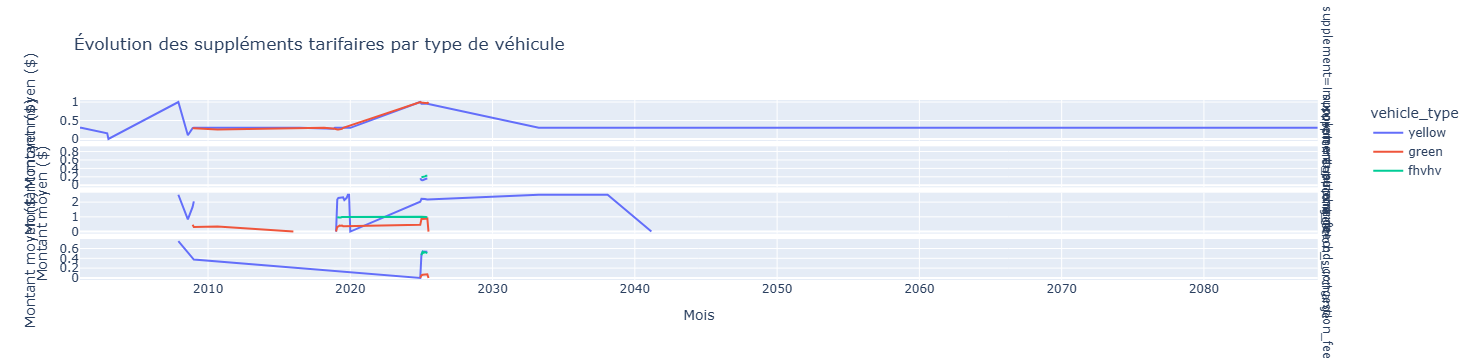

In [6]:
# Exercice : Évolution des nouveaux suppléments tarifaires
!spark-submit --master spark://spark-master:7077 /home/jovyan/work/pipeline/gold/gold_surcharges.py

import sys
sys.path.append("/home/jovyan/work/pipeline")
import pandas as pd
import plotly.express as px
from notebook_utils import read_gold_table

surcharges = read_gold_table("/gold/surcharges_evolution", refresh=True)
surcharges["date"] = pd.to_datetime(dict(year=surcharges.year, month=surcharges.month, day=1))

fig = px.line(
    surcharges.sort_values("date"),
    x="date", y="montant_moyen", color="vehicle_type",
    facet_row="supplement",
    title="Évolution des suppléments tarifaires par type de véhicule",
    labels={"montant_moyen": "Montant moyen ($)", "date": "Mois"},
)
fig.update_yaxes(matches=None)
fig.show()

26/08/26 11:22:29 INFO SparkContext: Running Spark version 3.5.0
26/08/26 11:22:29 INFO SparkContext: OS info Linux, 5.15.167.4-microsoft-standard-WSL2, amd64
26/08/26 11:22:29 INFO SparkContext: Java version 17.0.8.1
26/08/26 11:22:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/08/26 11:22:29 INFO ResourceUtils: ==============================================================
26/08/26 11:22:29 INFO ResourceUtils: No custom resources configured for spark.driver.
26/08/26 11:22:29 INFO ResourceUtils: ==============================================================
26/08/26 11:22:29 INFO SparkContext: Submitted application: gold-flows
26/08/26 11:22:29 INFO ResourceProfile: Default ResourceProfile created, executor resources: Map(memory -> name: memory, amount: 1024, script: , vendor: , offHeap -> name: offHeap, amount: 0, script: , vendor: ), task resources: Map(cpus -> name: cpus, amount: 1.0)
26/08/26 11:2

/opt/conda/lib/python3.11/site-packages/holoviews/__init__.py:81: FutureWarning:

param.version.Version has been deprecated and will be removed in a future version.

/opt/conda/lib/python3.11/site-packages/param/version.py:200: FutureWarning:

param.version.run_cmd has been deprecated and will be removed in a future version.

/opt/conda/lib/python3.11/site-packages/panel/config.py:35: FutureWarning:

param.version.Version has been deprecated and will be removed in a future version.

/opt/conda/lib/python3.11/site-packages/param/version.py:200: FutureWarning:

param.version.run_cmd has been deprecated and will be removed in a future version.



<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
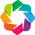

:Chord   [source,target]   (value)

In [7]:
# Exercice : Diagramme en corde des flux pickup/dropoff
!spark-submit --master spark://spark-master:7077 /home/jovyan/work/pipeline/gold/gold_flows.py

import holoviews as hv
hv.extension("bokeh")

flows_borough = read_gold_table("/gold/flows_by_borough", refresh=True)
flows_borough = flows_borough.dropna(subset=["pickup_borough", "dropoff_borough"])
agg = flows_borough.groupby(["pickup_borough", "dropoff_borough"])["nb_courses"].sum().reset_index()
# on garde les flux INTER-arrondissement (intra-arrondissement écraserait
# visuellement le reste, Manhattan->Manhattan étant très majoritaire)
agg = agg[agg["pickup_borough"] != agg["dropoff_borough"]]

boroughs = sorted(set(agg["pickup_borough"]) | set(agg["dropoff_borough"]))
index_of = {b: i for i, b in enumerate(boroughs)}
nodes = hv.Dataset(pd.DataFrame({"index": range(len(boroughs)), "name": boroughs}), "index")
links = pd.DataFrame({
    "source": agg["pickup_borough"].map(index_of),
    "target": agg["dropoff_borough"].map(index_of),
    "value": agg["nb_courses"],
})

chord = hv.Chord((links, nodes)).opts(
    node_color="name", cmap="Category10", edge_color="source", edge_cmap="Category10",
    labels="name", width=600, height=600,
    title="Flux de courses entre arrondissements (pickup -> dropoff)",
)
chord

26/08/26 11:26:48 INFO SparkContext: Running Spark version 3.5.0
26/08/26 11:26:48 INFO SparkContext: OS info Linux, 5.15.167.4-microsoft-standard-WSL2, amd64
26/08/26 11:26:48 INFO SparkContext: Java version 17.0.8.1
26/08/26 11:26:48 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/08/26 11:26:48 INFO ResourceUtils: ==============================================================
26/08/26 11:26:48 INFO ResourceUtils: No custom resources configured for spark.driver.
26/08/26 11:26:48 INFO ResourceUtils: ==============================================================
26/08/26 11:26:48 INFO SparkContext: Submitted application: gold-price-ridgeline
26/08/26 11:26:48 INFO ResourceProfile: Default ResourceProfile created, executor resources: Map(memory -> name: memory, amount: 1024, script: , vendor: , offHeap -> name: offHeap, amount: 0, script: , vendor: ), task resources: Map(cpus -> name: cpus, amount: 1.0)
26/

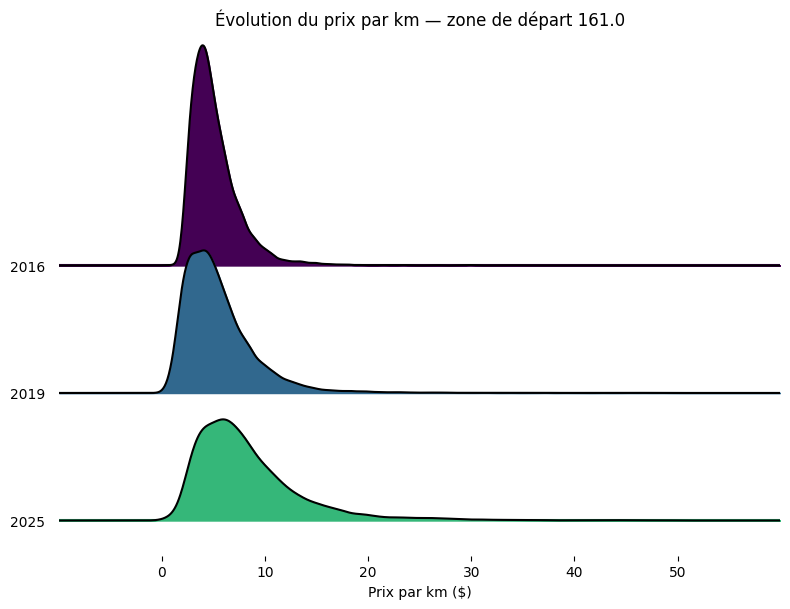

In [8]:
# Exercice : Ridgeline plot de l'évolution du prix par zone de départ
!spark-submit --master spark://spark-master:7077 /home/jovyan/work/pipeline/gold/gold_price_ridgeline.py

import joypy
import matplotlib.pyplot as plt

price_data = read_gold_table("/gold/price_per_km_by_zone_year", refresh=True)

# Zone de départ à visualiser : paramétrable, ici on prend celle qui a le
# plus de lignes échantillonnées pour garantir une distribution lisible
# sur toutes les années.
zone_id = price_data["pickup_zone_id"].value_counts().idxmax()
subset = price_data[price_data["pickup_zone_id"] == zone_id]

fig, axes = joypy.joyplot(
    subset, by="year", column="price_per_km",
    figsize=(8, 6), overlap=2, colormap=plt.cm.viridis,
    title=f"Évolution du prix par km — zone de départ {zone_id}",
)
plt.xlabel("Prix par km ($)")
plt.show()

26/08/26 12:03:20 INFO SparkContext: Running Spark version 3.5.0
26/08/26 12:03:20 INFO SparkContext: OS info Linux, 5.15.167.4-microsoft-standard-WSL2, amd64
26/08/26 12:03:20 INFO SparkContext: Java version 17.0.8.1
26/08/26 12:03:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/08/26 12:03:28 INFO ResourceUtils: ==============================================================
26/08/26 12:03:28 INFO ResourceUtils: No custom resources configured for spark.driver.
26/08/26 12:03:28 INFO ResourceUtils: ==============================================================
26/08/26 12:03:28 INFO SparkContext: Submitted application: gold-heatmap
26/08/26 12:03:28 INFO ResourceProfile: Default ResourceProfile created, executor resources: Map(memory -> name: memory, amount: 1024, script: , vendor: , offHeap -> name: offHeap, amount: 0, script: , vendor: ), task resources: Map(cpus -> name: cpus, amount: 1.0)
26/08/26 12

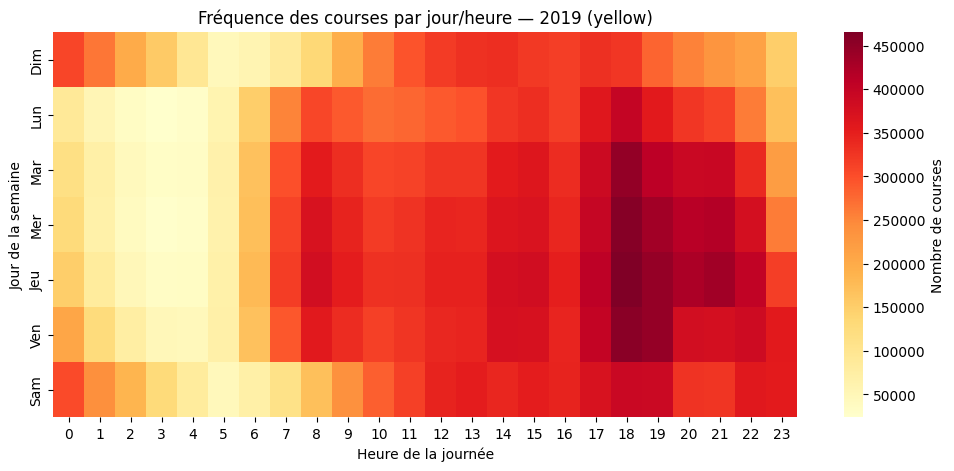

hour_of_day,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Dim,310161,264620,200827,155144,95739,45881,57650,86172,133394,193346,...,332902,320635,316279,332252,325221,280462,253304,233239,212769,150902
Lun,90490,53413,34435,23904,30388,59874,151329,253169,307188,290725,...,324601,334339,316797,360510,398243,356746,324249,312945,259957,169966
Mar,115344,70949,44435,31719,33732,65413,168413,299550,354430,332671,...,354978,362099,335644,389247,446651,408881,392635,394626,338410,221978
Mer,127454,68725,40687,27198,30234,64906,172223,310601,371125,345169,...,365402,369694,342524,397258,458639,434153,412508,418099,378746,259929
Jeu,150273,83956,48733,32823,34512,67565,177708,318736,380018,352816,...,377673,381314,350542,407878,465441,445723,424370,434790,403939,316536
Ven,208337,126152,75813,49758,45758,69898,167429,291338,357297,334452,...,375129,372794,344034,401311,455100,445375,380021,378598,386223,356489
Sam,303444,240212,185896,129453,82721,46310,70871,110143,169545,239043,...,342429,351744,345828,371561,392069,391084,327926,326736,358993,354831


In [9]:
# Exercice : Fonction heatmap(annee) : fréquence des courses par jour/heure et par type de véhicule
!spark-submit --master spark://spark-master:7077 /home/jovyan/work/pipeline/gold/gold_heatmap.py

import seaborn as sns
import matplotlib.pyplot as plt

_heatmap_data = read_gold_table("/gold/rides_by_dow_hour", refresh=True)
_DOW_LABELS = {1: "Dim", 2: "Lun", 3: "Mar", 4: "Mer", 5: "Jeu", 6: "Ven", 7: "Sam"}

def heatmap(annee, vehicle_type=None):
    """Heatmap jour de la semaine x heure de la journée de la fréquence des
    courses, pour l'année donnée. Si vehicle_type est précisé, filtre sur
    ce seul type ; sinon agrège les 4 types ensemble."""
    data = _heatmap_data[_heatmap_data["year"] == annee]
    if vehicle_type:
        data = data[data["vehicle_type"] == vehicle_type]
    pivot = (
        data.groupby(["day_of_week", "hour_of_day"])["nb_courses"].sum()
        .unstack(fill_value=0)
        .reindex(index=range(1, 8), columns=range(24), fill_value=0)
    )
    pivot.index = [_DOW_LABELS[i] for i in pivot.index]

    plt.figure(figsize=(12, 5))
    title = f"Fréquence des courses par jour/heure — {annee}"
    if vehicle_type:
        title += f" ({vehicle_type})"
    sns.heatmap(pivot, cmap="YlOrRd", cbar_kws={"label": "Nombre de courses"})
    plt.title(title)
    plt.xlabel("Heure de la journée")
    plt.ylabel("Jour de la semaine")
    plt.show()
    return pivot

# Exemple d'appel :
heatmap(2019, vehicle_type="yellow")

### 5. Écart de prix selon la météo

*(cellule ajoutée : le sujet liste 5 analyses Gold dans son énoncé mais ce
notebook ne fournissait que 4 cellules "À COMPLÉTER" — celle-ci comble
l'écart pour couvrir intégralement les 5 analyses demandées.)*

26/08/26 12:09:52 INFO SparkContext: Running Spark version 3.5.0
26/08/26 12:09:52 INFO SparkContext: OS info Linux, 5.15.167.4-microsoft-standard-WSL2, amd64
26/08/26 12:09:52 INFO SparkContext: Java version 17.0.8.1
26/08/26 12:09:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/08/26 12:09:52 INFO ResourceUtils: ==============================================================
26/08/26 12:09:52 INFO ResourceUtils: No custom resources configured for spark.driver.
26/08/26 12:09:52 INFO ResourceUtils: ==============================================================
26/08/26 12:09:52 INFO SparkContext: Submitted application: gold-weather-price
26/08/26 12:09:52 INFO ResourceProfile: Default ResourceProfile created, executor resources: Map(memory -> name: memory, amount: 1024, script: , vendor: , offHeap -> name: offHeap, amount: 0, script: , vendor: ), task resources: Map(cpus -> name: cpus, amount: 1.0)
26/08

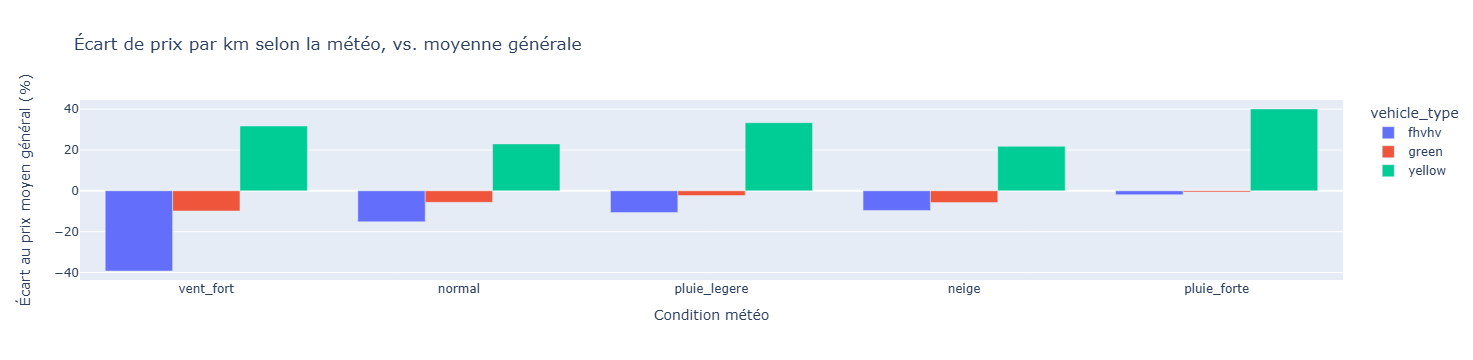

,vehicle_type,weather_bucket,prix_moyen_bucket,nb_courses,prix_moyen_general,ecart_pct
0,fhvhv,pluie_forte,4.419208,4180697,4.504071,-1.884153
1,fhvhv,normal,3.821041,186069709,4.504071,-15.164733
2,fhvhv,pluie_legere,4.024637,34557374,4.504071,-10.644470
3,yellow,normal,5.538328,114756801,4.504071,22.962704
4,yellow,pluie_legere,6.006097,16318864,4.504071,33.348167
5,yellow,pluie_forte,6.308622,1679337,4.504071,40.064865
6,fhvhv,neige,4.071370,4418721,4.504071,-9.606902
7,yellow,neige,5.486271,2966958,4.504071,21.806919
8,yellow,vent_fort,5.933850,113182,4.504071,31.744145
9,green,neige,4.245195,277913,4.504071,-5.747602


In [10]:
# Exercice : Écart de prix selon la météo
!spark-submit --master spark://spark-master:7077 /home/jovyan/work/pipeline/gold/gold_weather_price.py

weather_price = read_gold_table("/gold/price_by_weather", refresh=True)

fig = px.bar(
    weather_price.sort_values("ecart_pct"),
    x="weather_bucket", y="ecart_pct", color="vehicle_type", barmode="group",
    title="Écart de prix par km selon la météo, vs. moyenne générale",
    labels={"ecart_pct": "Écart au prix moyen général (%)", "weather_bucket": "Condition météo"},
)
fig.show()
weather_price

In [11]:
from hdfs import InsecureClient
client = InsecureClient("http://namenode:9870", user="jovyan")
for path, dirs, files in client.walk("/gold"):
    print(path, "->", dirs, files)

/gold -> ['flows_by_borough', 'flows_by_zone', 'price_by_weather', 'price_per_km_by_zone_year', 'rides_by_dow_hour', 'surcharges_evolution'] []
/gold/flows_by_borough -> [] ['_SUCCESS', 'part-00000-723d1484-1610-4339-b788-caaf154da37a-c000.snappy.parquet']
/gold/flows_by_zone -> [] ['_SUCCESS', 'part-00000-96fc907b-fca3-4660-aa70-7da2d3340cd5-c000.snappy.parquet', 'part-00001-96fc907b-fca3-4660-aa70-7da2d3340cd5-c000.snappy.parquet', 'part-00002-96fc907b-fca3-4660-aa70-7da2d3340cd5-c000.snappy.parquet', 'part-00003-96fc907b-fca3-4660-aa70-7da2d3340cd5-c000.snappy.parquet', 'part-00004-96fc907b-fca3-4660-aa70-7da2d3340cd5-c000.snappy.parquet', 'part-00005-96fc907b-fca3-4660-aa70-7da2d3340cd5-c000.snappy.parquet']
/gold/price_by_weather -> [] ['_SUCCESS', 'part-00000-6ce0addd-e3f9-4a36-8d6a-185129ba1b67-c000.snappy.parquet']
/gold/price_per_km_by_zone_year -> ['pickup_zone_id=1.0', 'pickup_zone_id=10.0', 'pickup_zone_id=100.0', 'pickup_zone_id=101.0', 'pickup_zone_id=102.0', 'pickup_zone